# N3 - LightGBM

**Models**:
1. **Baseline 1 + is_evening**: PhoBERT-v2-Pretrained + TF-IDF + Handcraft (with is_evening)
2. **Baseline 1 + hour_sin_cos**: PhoBERT-v2-Pretrained + TF-IDF + Handcraft (with hour_sin/cos)
3. **Baseline 2 + is_evening**: PhoBERT-v2-Finetuned + Handcraft (with is_evening)
4. **Baseline 2 + hour_sin_cos**: PhoBERT-v2-Finetuned + Handcraft (with hour_sin/cos)

**Note**: Using binary_logloss objective to avoid F1=0 issue

**Evaluation**: 10-Fold CV → Paired T-Test
**Metrics**: AUC, F1, Precision, Recall

In [19]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent.parent.parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from scipy import stats
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    precision_recall_curve
)

print(f"Project root: {PROJECT_ROOT}")
print(f"LightGBM version: {lgb.__version__}")

Project root: d:\Vietnamese-Fake-News-Detection
LightGBM version: 4.5.0


In [20]:
# Paths
ENCODED_DIR = PROJECT_ROOT / 'data' / 'encoded'
ANALYSIS_DIR = PROJECT_ROOT / 'data' / 'analysis'
TRAINED_DIR = PROJECT_ROOT / 'data' / 'trained' / 'early_fusion'
MODEL_DIR = PROJECT_ROOT / 'model' / 'early_fusion' / 'lightgbm'
FIGURES_DIR = PROJECT_ROOT / 'data' / 'figures' / 'training'

# Ensure directories exist
TRAINED_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Random state
RANDOM_STATE = 42
N_FOLDS = 10

## 1. Load Data

In [21]:
# Load CSV with labels and handcraft features
df = pd.read_csv(ENCODED_DIR / 'final_data_shuffled.csv')
labels = df['label'].values

print(f"Samples: {len(df)}")
print(f"Label distribution: {dict(pd.Series(labels).value_counts())}")

Samples: 4736
Label distribution: {0: 3929, 1: 807}


In [22]:
# Load selected features
with open(ANALYSIS_DIR / 'selected_features.txt', 'r') as f:
    all_features = [line.strip() for line in f.readlines()]

# Split into two variants
features_is_evening = [f for f in all_features if f not in ['feat_hour_sin', 'feat_hour_cos']]
features_hour_sin_cos = [f for f in all_features if f != 'feat_is_evening']

print(f"Features with is_evening ({len(features_is_evening)}): {features_is_evening}")
print(f"Features with hour_sin_cos ({len(features_hour_sin_cos)}): {features_hour_sin_cos}")

Features with is_evening (10): ['feat_avg_word_length', 'feat_comment_ratio', 'feat_digit_ratio', 'feat_fake_ratio', 'feat_is_evening', 'feat_like_ratio', 'feat_num_exclamation', 'feat_num_question', 'feat_num_sentences', 'feat_num_urls']
Features with hour_sin_cos (11): ['feat_avg_word_length', 'feat_comment_ratio', 'feat_digit_ratio', 'feat_fake_ratio', 'feat_hour_cos', 'feat_hour_sin', 'feat_like_ratio', 'feat_num_exclamation', 'feat_num_question', 'feat_num_sentences', 'feat_num_urls']


In [23]:
# Load embeddings
phobert_pretrain = np.load(ENCODED_DIR / 'phobertv2' / 'pretrained_embeddings.npy')
phobert_finetune = np.load(ENCODED_DIR / 'phobertv2' / 'finetuned_embeddings.npy')
tfidf_emb = np.load(ENCODED_DIR / 'tfidf' / 'tfidf_embeddings.npy')

print(f"PhoBERT pretrained: {phobert_pretrain.shape}")
print(f"PhoBERT finetuned: {phobert_finetune.shape}")
print(f"TF-IDF: {tfidf_emb.shape}")

# Handcraft features
handcraft_is_evening = df[features_is_evening].values
handcraft_hour_sin_cos = df[features_hour_sin_cos].values

print(f"\nHandcraft (is_evening): {handcraft_is_evening.shape}")
print(f"Handcraft (hour_sin_cos): {handcraft_hour_sin_cos.shape}")

PhoBERT pretrained: (4736, 88)
PhoBERT finetuned: (4736, 68)
TF-IDF: (4736, 120)

Handcraft (is_evening): (4736, 10)
Handcraft (hour_sin_cos): (4736, 11)


## 2. Define Model Configurations

In [24]:
# Model configurations
MODEL_CONFIGS = {
    'B1_is_evening': {
        'name': 'Baseline1 + is_evening',
        'baseline': 1,
        'time_type': 'is_evening',
        'embeddings': [phobert_pretrain, tfidf_emb],
        'handcraft': handcraft_is_evening,
        'feature_names': features_is_evening
    },
    'B1_hour_sin_cos': {
        'name': 'Baseline1 + hour_sin_cos',
        'baseline': 1,
        'time_type': 'hour_sin_cos',
        'embeddings': [phobert_pretrain, tfidf_emb],
        'handcraft': handcraft_hour_sin_cos,
        'feature_names': features_hour_sin_cos
    },
    'B2_is_evening': {
        'name': 'Baseline2 + is_evening',
        'baseline': 2,
        'time_type': 'is_evening',
        'embeddings': [phobert_finetune],
        'handcraft': handcraft_is_evening,
        'feature_names': features_is_evening
    },
    'B2_hour_sin_cos': {
        'name': 'Baseline2 + hour_sin_cos',
        'baseline': 2,
        'time_type': 'hour_sin_cos',
        'embeddings': [phobert_finetune],
        'handcraft': handcraft_hour_sin_cos,
        'feature_names': features_hour_sin_cos
    }
}

print("Model configurations:")
for key, config in MODEL_CONFIGS.items():
    total_dim = sum(e.shape[1] for e in config['embeddings']) + config['handcraft'].shape[1]
    print(f"  {key}: {config['name']} → {total_dim} dims")

Model configurations:
  B1_is_evening: Baseline1 + is_evening → 218 dims
  B1_hour_sin_cos: Baseline1 + hour_sin_cos → 219 dims
  B2_is_evening: Baseline2 + is_evening → 78 dims
  B2_hour_sin_cos: Baseline2 + hour_sin_cos → 79 dims


## 3. LightGBM Parameters

In [25]:
# LightGBM parameters - using binary_logloss to avoid F1=0
LGB_PARAMS = {
    'objective': 'binary',
    'metric': 'binary_logloss',  # Use logloss instead of auc to avoid F1=0
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'min_child_samples': 20,
    'is_unbalance': True,  # Handle class imbalance
    'verbose': -1,
    'random_state': RANDOM_STATE,
    'n_jobs': -1
}

NUM_BOOST_ROUND = 500
EARLY_STOPPING_ROUNDS = 50

print("LightGBM Parameters:")
for k, v in LGB_PARAMS.items():
    print(f"  {k}: {v}")

LightGBM Parameters:
  objective: binary
  metric: binary_logloss
  boosting_type: gbdt
  num_leaves: 31
  learning_rate: 0.05
  feature_fraction: 0.8
  bagging_fraction: 0.8
  bagging_freq: 5
  min_child_samples: 20
  is_unbalance: True
  verbose: -1
  random_state: 42
  n_jobs: -1


## 4. Evaluation Functions

In [26]:
def prepare_features(config):
    """Concatenate embeddings and handcraft features"""
    parts = config['embeddings'] + [config['handcraft']]
    return np.hstack(parts)

def find_optimal_threshold(y_true, y_prob):
    """Find threshold that maximizes F1 score"""
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
    best_idx = np.argmax(f1_scores)
    return thresholds[best_idx] if best_idx < len(thresholds) else 0.5

def evaluate_fold(y_true, y_prob, threshold=0.5):
    """Calculate metrics for a fold"""
    y_pred = (y_prob >= threshold).astype(int)
    return {
        'auc': roc_auc_score(y_true, y_prob),
        'f1': f1_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'threshold': threshold
    }

In [27]:
def train_evaluate_cv(X, y, n_folds=10, random_state=42):
    """Train and evaluate with K-Fold CV"""
    kf = StratifiedKFold(n_splits=n_folds, shuffle=False)
    fold_results = []
    feature_importance_list = []
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        
        # Create LightGBM datasets
        train_data = lgb.Dataset(X_train, label=y_train)
        val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)
        
        # Train model with early stopping
        model = lgb.train(
            LGB_PARAMS,
            train_data,
            num_boost_round=NUM_BOOST_ROUND,
            valid_sets=[val_data],
            callbacks=[
                lgb.early_stopping(stopping_rounds=EARLY_STOPPING_ROUNDS, verbose=False),
                lgb.log_evaluation(period=0)
            ]
        )
        
        # Predict probabilities
        y_prob = model.predict(X_val)
        
        # Find optimal threshold
        opt_threshold = find_optimal_threshold(y_val, y_prob)
        
        # Evaluate
        metrics = evaluate_fold(y_val, y_prob, opt_threshold)
        metrics['fold'] = fold + 1
        metrics['best_iteration'] = model.best_iteration
        fold_results.append(metrics)
        
        # Store feature importance
        feature_importance_list.append(model.feature_importance(importance_type='gain'))
    
    # Average feature importance
    avg_importance = np.mean(feature_importance_list, axis=0)
    
    return fold_results, avg_importance

In [28]:
def train_final_model(X, y, random_state=42):
    """Train final model on full data with cross-validation for optimal rounds"""
    # First, find optimal number of rounds using CV
    train_data = lgb.Dataset(X, label=y)
    
    cv_results = lgb.cv(
        LGB_PARAMS,
        train_data,
        num_boost_round=NUM_BOOST_ROUND,
        nfold=5,
        callbacks=[
            lgb.early_stopping(stopping_rounds=EARLY_STOPPING_ROUNDS, verbose=False),
            lgb.log_evaluation(period=0)
        ],
        seed=random_state
    )
    
    # Get the key from cv_results (changes based on metric)
    key = 'valid binary_logloss-mean'
    best_rounds = len(cv_results[key])
    
    # Train final model
    final_model = lgb.train(
        LGB_PARAMS,
        train_data,
        num_boost_round=best_rounds
    )
    
    # Find optimal threshold
    y_prob = final_model.predict(X)
    opt_threshold = find_optimal_threshold(y, y_prob)
    
    return final_model, opt_threshold, best_rounds

## 5. Train All Models

In [29]:
# Store results
all_results = {}
all_fold_metrics = {}

for model_key, config in tqdm(MODEL_CONFIGS.items(), desc="Training models"):
    print(f"\n{'='*60}")
    print(f"Training: {config['name']}")
    print(f"{'='*60}")
    
    # Prepare features
    X = prepare_features(config)
    y = labels
    print(f"Feature shape: {X.shape}")
    
    # 10-Fold CV
    fold_results, feature_importance = train_evaluate_cv(
        X, y, n_folds=N_FOLDS, random_state=RANDOM_STATE
    )
    
    # Calculate mean metrics
    fold_df = pd.DataFrame(fold_results)
    mean_metrics = {
        'auc_mean': fold_df['auc'].mean(),
        'auc_std': fold_df['auc'].std(),
        'f1_mean': fold_df['f1'].mean(),
        'f1_std': fold_df['f1'].std(),
        'precision_mean': fold_df['precision'].mean(),
        'precision_std': fold_df['precision'].std(),
        'recall_mean': fold_df['recall'].mean(),
        'recall_std': fold_df['recall'].std(),
        'threshold_mean': fold_df['threshold'].mean(),
        'best_iteration_mean': fold_df['best_iteration'].mean()
    }
    
    print(f"\n10-Fold CV Results:")
    print(f"  AUC:       {mean_metrics['auc_mean']:.4f} ± {mean_metrics['auc_std']:.4f}")
    print(f"  F1:        {mean_metrics['f1_mean']:.4f} ± {mean_metrics['f1_std']:.4f}")
    print(f"  Precision: {mean_metrics['precision_mean']:.4f} ± {mean_metrics['precision_std']:.4f}")
    print(f"  Recall:    {mean_metrics['recall_mean']:.4f} ± {mean_metrics['recall_std']:.4f}")
    print(f"  Threshold: {mean_metrics['threshold_mean']:.4f}")
    print(f"  Avg Iterations: {mean_metrics['best_iteration_mean']:.0f}")
    
    # Train final model on full data
    final_model, opt_threshold, best_rounds = train_final_model(X, y, RANDOM_STATE)
    print(f"\nFinal model: {best_rounds} rounds, threshold={opt_threshold:.4f}")
    
    # Save results
    all_fold_metrics[model_key] = fold_df
    all_results[model_key] = {
        'config': config['name'],
        'baseline': config['baseline'],
        'time_type': config['time_type'],
        'mean_metrics': mean_metrics,
        'fold_results': fold_results,
        'model': final_model,
        'threshold': opt_threshold,
        'feature_importance': feature_importance,
        'feature_names': config['feature_names']
    }

Training models:   0%|          | 0/4 [00:00<?, ?it/s]


Training: Baseline1 + is_evening
Feature shape: (4736, 218)

10-Fold CV Results:
  AUC:       0.9437 ± 0.0098
  F1:        0.7522 ± 0.0259
  Precision: 0.7450 ± 0.0692
  Recall:    0.7706 ± 0.0754
  Threshold: 0.4412
  Avg Iterations: 182


Training models:  25%|██▌       | 1/4 [00:12<00:38, 12.83s/it]


Final model: 190 rounds, threshold=0.8149

Training: Baseline1 + hour_sin_cos
Feature shape: (4736, 219)

10-Fold CV Results:
  AUC:       0.9440 ± 0.0086
  F1:        0.7562 ± 0.0304
  Precision: 0.7462 ± 0.0861
  Recall:    0.7807 ± 0.0745
  Threshold: 0.4330
  Avg Iterations: 191


Training models:  50%|█████     | 2/4 [00:24<00:24, 12.34s/it]


Final model: 180 rounds, threshold=0.7853

Training: Baseline2 + is_evening
Feature shape: (4736, 78)

10-Fold CV Results:
  AUC:       0.9790 ± 0.0057
  F1:        0.8837 ± 0.0174
  Precision: 0.8878 ± 0.0468
  Recall:    0.8823 ± 0.0305
  Threshold: 0.5977
  Avg Iterations: 86


Training models:  75%|███████▌  | 3/4 [00:28<00:08,  8.28s/it]


Final model: 95 rounds, threshold=0.7181

Training: Baseline2 + hour_sin_cos
Feature shape: (4736, 79)

10-Fold CV Results:
  AUC:       0.9792 ± 0.0053
  F1:        0.8851 ± 0.0164
  Precision: 0.8909 ± 0.0399
  Recall:    0.8811 ± 0.0266
  Threshold: 0.6224
  Avg Iterations: 85


Training models: 100%|██████████| 4/4 [00:31<00:00,  7.87s/it]


Final model: 76 rounds, threshold=0.6838


## 6. Save Results & Models

In [30]:
# Save fold results
for model_key, fold_df in all_fold_metrics.items():
    output_path = TRAINED_DIR / f'lgbm_{model_key}_folds.csv'
    fold_df.to_csv(output_path, index=False)
    print(f"Saved: {output_path}")

# Save final models
for model_key, result in all_results.items():
    model_path = MODEL_DIR / f'{model_key}_model.txt'
    result['model'].save_model(str(model_path))
    print(f"Saved: {model_path}")
    
    # Save metadata
    meta_path = MODEL_DIR / f'{model_key}_meta.joblib'
    joblib.dump({
        'threshold': result['threshold'],
        'feature_names': result['feature_names'],
        'config': result['config']
    }, meta_path)

Saved: d:\Vietnamese-Fake-News-Detection\data\trained\early_fusion\lgbm_B1_is_evening_folds.csv
Saved: d:\Vietnamese-Fake-News-Detection\data\trained\early_fusion\lgbm_B1_hour_sin_cos_folds.csv
Saved: d:\Vietnamese-Fake-News-Detection\data\trained\early_fusion\lgbm_B2_is_evening_folds.csv
Saved: d:\Vietnamese-Fake-News-Detection\data\trained\early_fusion\lgbm_B2_hour_sin_cos_folds.csv
Saved: d:\Vietnamese-Fake-News-Detection\model\early_fusion\lightgbm\B1_is_evening_model.txt
Saved: d:\Vietnamese-Fake-News-Detection\model\early_fusion\lightgbm\B1_hour_sin_cos_model.txt
Saved: d:\Vietnamese-Fake-News-Detection\model\early_fusion\lightgbm\B2_is_evening_model.txt
Saved: d:\Vietnamese-Fake-News-Detection\model\early_fusion\lightgbm\B2_hour_sin_cos_model.txt


## 7. Summary Table

In [31]:
# Create summary table
summary_data = []
for model_key, result in all_results.items():
    m = result['mean_metrics']
    summary_data.append({
        'Model': result['config'],
        'Baseline': result['baseline'],
        'Time Feature': result['time_type'],
        'AUC': f"{m['auc_mean']:.4f}±{m['auc_std']:.4f}",
        'F1': f"{m['f1_mean']:.4f}±{m['f1_std']:.4f}",
        'Precision': f"{m['precision_mean']:.4f}±{m['precision_std']:.4f}",
        'Recall': f"{m['recall_mean']:.4f}±{m['recall_std']:.4f}",
        'Threshold': f"{result['threshold']:.4f}"
    })

summary_df = pd.DataFrame(summary_data)
print("\n" + "="*100)
print("SUMMARY - LIGHTGBM")
print("="*100)
display(summary_df)


SUMMARY - LIGHTGBM


,Model,Baseline,Time Feature,AUC,F1,Precision,Recall,Threshold
0,Baseline1 + is_evening,1,is_evening,0.9437±0.0098,0.7522±0.0259,0.7450±0.0692,0.7706±0.0754,0.8149
1,Baseline1 + hour_sin_cos,1,hour_sin_cos,0.9440±0.0086,0.7562±0.0304,0.7462±0.0861,0.7807±0.0745,0.7853
2,Baseline2 + is_evening,2,is_evening,0.9790±0.0057,0.8837±0.0174,0.8878±0.0468,0.8823±0.0305,0.7181
3,Baseline2 + hour_sin_cos,2,hour_sin_cos,0.9792±0.0053,0.8851±0.0164,0.8909±0.0399,0.8811±0.0266,0.6838


## 8. Paired T-Test Analysis

In [32]:
def paired_ttest(fold_df1, fold_df2, metric='f1'):
    scores1 = fold_df1[metric].values
    scores2 = fold_df2[metric].values
    t_stat, p_value = stats.ttest_rel(scores1, scores2)
    return t_stat, p_value, scores1.mean() - scores2.mean()

COMPARISON_PAIRS = [
    ('B1_is_evening', 'B1_hour_sin_cos', 'Baseline 1: is_evening vs hour_sin_cos'),
    ('B2_is_evening', 'B2_hour_sin_cos', 'Baseline 2: is_evening vs hour_sin_cos'),
    ('B1_is_evening', 'B2_is_evening', 'is_evening: Baseline 1 vs Baseline 2'),
    ('B1_hour_sin_cos', 'B2_hour_sin_cos', 'hour_sin_cos: Baseline 1 vs Baseline 2'),
]

print("Paired T-Test Results (F1 Score):")
print("="*80)

ttest_results = []
for model1, model2, desc in COMPARISON_PAIRS:
    t_stat, p_value, diff = paired_ttest(
        all_fold_metrics[model1], all_fold_metrics[model2], 'f1'
    )
    sig = "*" if p_value < 0.05 else ""
    print(f"\n{desc}")
    print(f"  t-stat: {t_stat:.4f}, p-value: {p_value:.4f} {sig}")
    print(f"  Mean diff: {diff:.4f}")
    
    ttest_results.append({
        'comparison': desc, 'model1': model1, 'model2': model2,
        't_stat': t_stat, 'p_value': p_value, 'significant': p_value < 0.05,
        'mean_diff': diff
    })

ttest_df = pd.DataFrame(ttest_results)
ttest_df.to_csv(TRAINED_DIR / 'lgbm_paired_ttest.csv', index=False)

Paired T-Test Results (F1 Score):

Baseline 1: is_evening vs hour_sin_cos
  t-stat: -0.9755, p-value: 0.3548 
  Mean diff: -0.0041

Baseline 2: is_evening vs hour_sin_cos
  t-stat: -0.5598, p-value: 0.5893 
  Mean diff: -0.0014

is_evening: Baseline 1 vs Baseline 2
  t-stat: -15.6394, p-value: 0.0000 *
  Mean diff: -0.1316

hour_sin_cos: Baseline 1 vs Baseline 2
  t-stat: -10.6305, p-value: 0.0000 *
  Mean diff: -0.1289


## 9. Visualizations

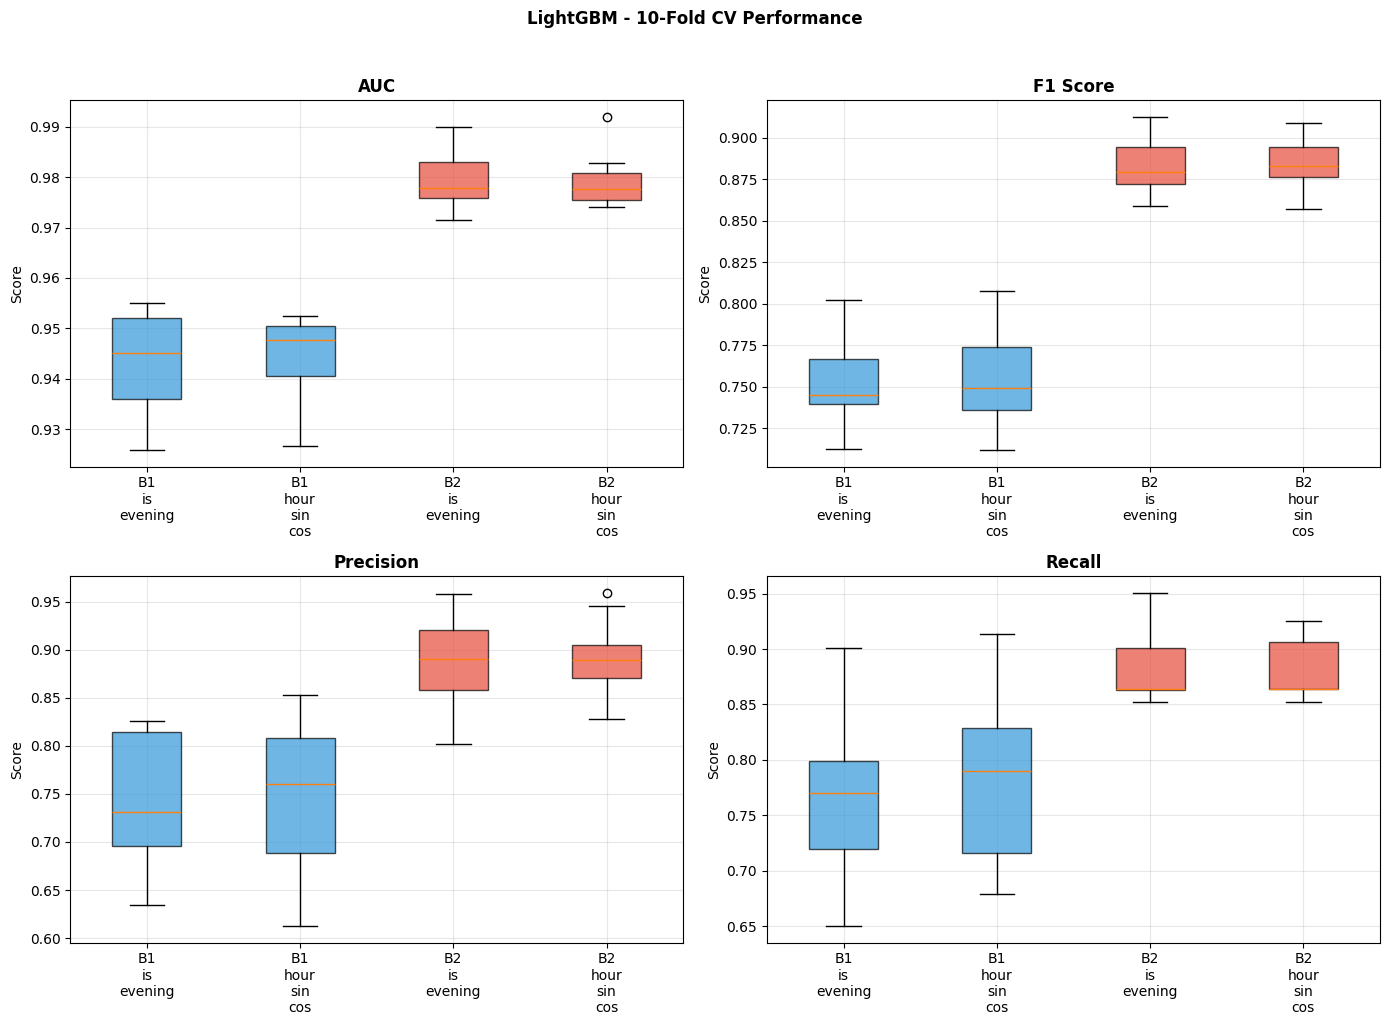

In [33]:
# Box plot comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics_to_plot = ['auc', 'f1', 'precision', 'recall']
titles = ['AUC', 'F1 Score', 'Precision', 'Recall']

for ax, metric, title in zip(axes.flatten(), metrics_to_plot, titles):
    data_to_plot = []
    labels_plot = []
    for model_key, fold_df in all_fold_metrics.items():
        data_to_plot.append(fold_df[metric].values)
        labels_plot.append(model_key.replace('_', '\n'))
    
    bp = ax.boxplot(data_to_plot, labels=labels_plot, patch_artist=True)
    
    colors = ['#3498db', '#3498db', '#e74c3c', '#e74c3c']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Score')
    ax.grid(True, alpha=0.3)

plt.suptitle('LightGBM - 10-Fold CV Performance', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'lgbm_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

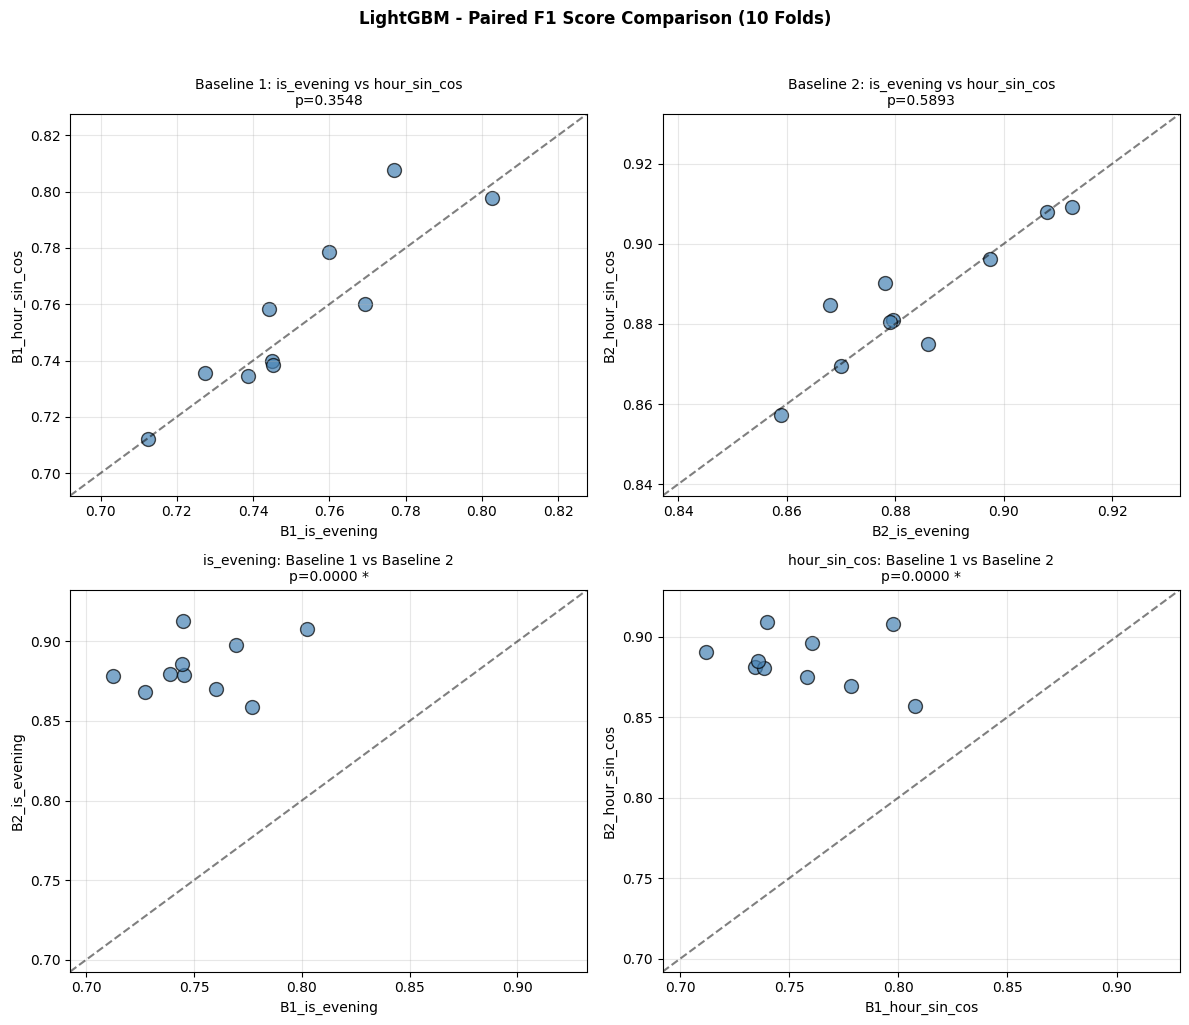

In [34]:
# Paired comparison plots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, (model1, model2, desc) in zip(axes.flatten(), COMPARISON_PAIRS):
    scores1 = all_fold_metrics[model1]['f1'].values
    scores2 = all_fold_metrics[model2]['f1'].values
    
    ax.scatter(scores1, scores2, alpha=0.7, s=100, c='steelblue', edgecolors='black')
    
    min_val = min(scores1.min(), scores2.min()) - 0.02
    max_val = max(scores1.max(), scores2.max()) + 0.02
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5)
    
    t_stat, p_value = stats.ttest_rel(scores1, scores2)
    sig_text = f"p={p_value:.4f}" + (" *" if p_value < 0.05 else "")
    
    ax.set_xlabel(model1)
    ax.set_ylabel(model2)
    ax.set_title(f"{desc}\n{sig_text}", fontsize=10)
    ax.set_xlim(min_val, max_val)
    ax.set_ylim(min_val, max_val)
    ax.grid(True, alpha=0.3)

plt.suptitle('LightGBM - Paired F1 Score Comparison (10 Folds)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'lgbm_paired_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

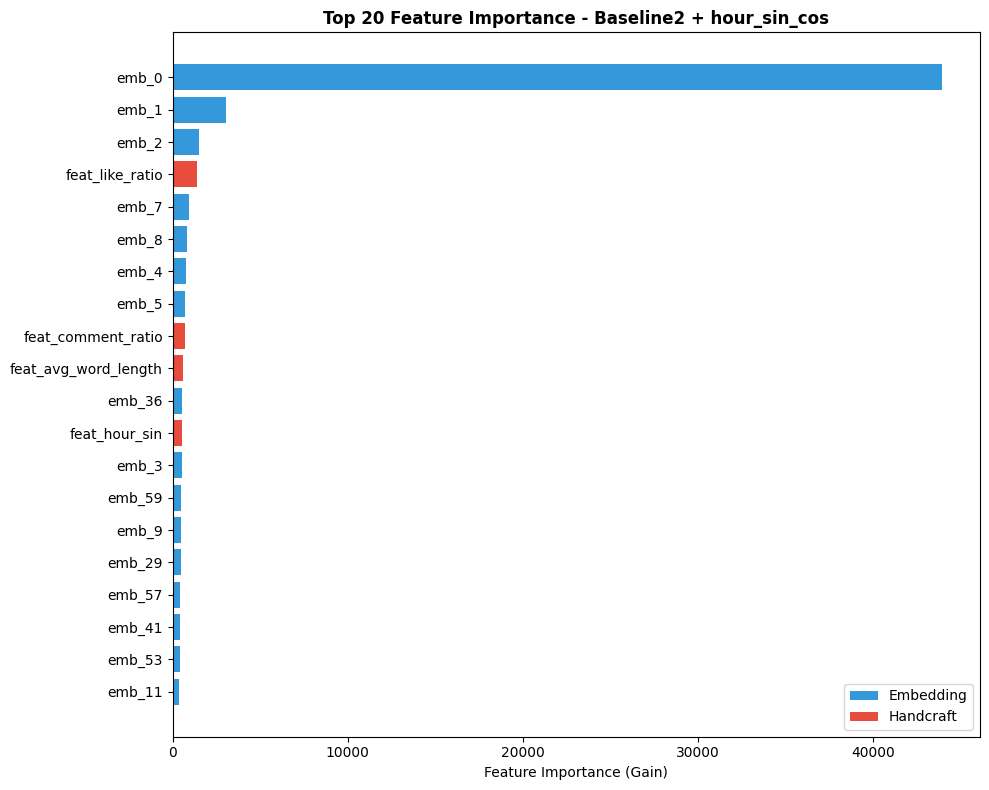

In [35]:
# Feature importance for best model
best_key = max(all_results.keys(), key=lambda k: all_results[k]['mean_metrics']['f1_mean'])
best_result = all_results[best_key]

# Get top 20 important features (last features are handcraft)
importance = best_result['feature_importance']
n_features = len(importance)

# Create feature names for all dimensions
config = MODEL_CONFIGS[best_key]
emb_dims = sum(e.shape[1] for e in config['embeddings'])
handcraft_dims = config['handcraft'].shape[1]

feature_names_full = [f"emb_{i}" for i in range(emb_dims)] + config['feature_names']

# Get top 20
top_idx = np.argsort(importance)[-20:]
top_names = [feature_names_full[i] if i < len(feature_names_full) else f"feat_{i}" for i in top_idx]
top_importance = importance[top_idx]

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#e74c3c' if 'feat_' in n else '#3498db' for n in top_names]
ax.barh(range(len(top_names)), top_importance, color=colors)
ax.set_yticks(range(len(top_names)))
ax.set_yticklabels(top_names)
ax.set_xlabel('Feature Importance (Gain)')
ax.set_title(f'Top 20 Feature Importance - {best_result["config"]}', fontweight='bold')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#3498db', label='Embedding'),
                   Patch(facecolor='#e74c3c', label='Handcraft')]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'lgbm_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Summary

In [36]:
print("="*70)
print("LIGHTGBM TRAINING COMPLETE")
print("="*70)

print(f"\n📊 Models trained: {len(all_results)}")
for key, result in all_results.items():
    m = result['mean_metrics']
    print(f"  • {result['config']}: F1={m['f1_mean']:.4f}, AUC={m['auc_mean']:.4f}")

print(f"\n📁 Output files:")
print(f"  • Fold results: {TRAINED_DIR}")
print(f"  • Models: {MODEL_DIR}")
print(f"  • Figures: {FIGURES_DIR}")

best_result = all_results[best_key]
print(f"\n🏆 Best model: {best_result['config']}")
print(f"   F1: {best_result['mean_metrics']['f1_mean']:.4f}")
print(f"   AUC: {best_result['mean_metrics']['auc_mean']:.4f}")

LIGHTGBM TRAINING COMPLETE

📊 Models trained: 4
  • Baseline1 + is_evening: F1=0.7522, AUC=0.9437
  • Baseline1 + hour_sin_cos: F1=0.7562, AUC=0.9440
  • Baseline2 + is_evening: F1=0.8837, AUC=0.9790
  • Baseline2 + hour_sin_cos: F1=0.8851, AUC=0.9792

📁 Output files:
  • Fold results: d:\Vietnamese-Fake-News-Detection\data\trained\early_fusion
  • Models: d:\Vietnamese-Fake-News-Detection\model\early_fusion\lightgbm
  • Figures: d:\Vietnamese-Fake-News-Detection\data\figures\training

🏆 Best model: Baseline2 + hour_sin_cos
   F1: 0.8851
   AUC: 0.9792
